# Project Data Science
# Segmentasi Pelanggan Berdasarkan Pola Transaksi Menggunakan K-Means Clustering

**Framework:** CRISP-DM

**Dataset:** UCI Online Retail

**Tujuan:** menemukan kelompok pelanggan berdasarkan perilaku transaksi untuk membantu memahami pola pelanggan.

> Jalankan notebook dari atas ke bawah. Semua angka hasil evaluasi harus berasal dari eksekusi aktual notebook.


## 1. Business Understanding

### Latar Belakang
Data transaksi retail menyimpan informasi mengenai pola pembelian pelanggan. Jumlah transaksi yang besar membuat pengelompokan pelanggan secara manual menjadi kurang efektif.

Project ini menggunakan clustering untuk menemukan kelompok pelanggan berdasarkan karakteristik transaksi.

### Rumusan Masalah
1. Bagaimana membentuk fitur yang menggambarkan perilaku pelanggan dari data transaksi?
2. Berapa jumlah cluster yang sesuai untuk segmentasi pelanggan?
3. Bagaimana karakteristik setiap cluster yang terbentuk?

### Tujuan
1. Melakukan segmentasi pelanggan menggunakan K-Means.
2. Menentukan jumlah cluster menggunakan Elbow Method dan Silhouette Score.
3. Mendeskripsikan karakteristik setiap cluster.

### Manfaat
Hasil segmentasi dapat digunakan sebagai dasar analisis pelanggan, misalnya untuk membedakan pelanggan berdasarkan frekuensi, nilai transaksi, jumlah barang, dan recency.


In [1]:
# Import library
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

print("Library berhasil diimpor.")


Library berhasil diimpor.


## 2. Data Understanding

Dataset yang digunakan adalah **Online Retail** dari UCI Machine Learning Repository. Dataset berisi transaksi perusahaan retail online di Inggris pada periode 1 Desember 2010 sampai 9 Desember 2011. UCI mencatat 541.909 transaksi dan file transaksi memiliki 8 kolom.

Sumber:
https://archive.ics.uci.edu/dataset/352/online+retail


In [2]:
# Download dataset dari UCI jika belum tersedia
DATA_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"
DATA_FILE = "Online_Retail.xlsx"

if not os.path.exists(DATA_FILE):
    import urllib.request
    print("Mengunduh dataset dari UCI...")
    urllib.request.urlretrieve(DATA_URL, DATA_FILE)
    print("Download selesai.")

df = pd.read_excel(DATA_FILE)

print("Ukuran dataset:", df.shape)
display(df.head())


Ukuran dataset: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
# Informasi dataset
print("Informasi dataset:")
df.info()

print("\nJumlah missing value:")
display(df.isna().sum())

print("\nStatistik numerik:")
display(df.describe())


Informasi dataset:
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 40.0+ MB

Jumlah missing value:


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


Statistik numerik:


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


Jumlah invoice: 25900
Jumlah customer: 4372
Jumlah produk: 4070
Jumlah negara: 38


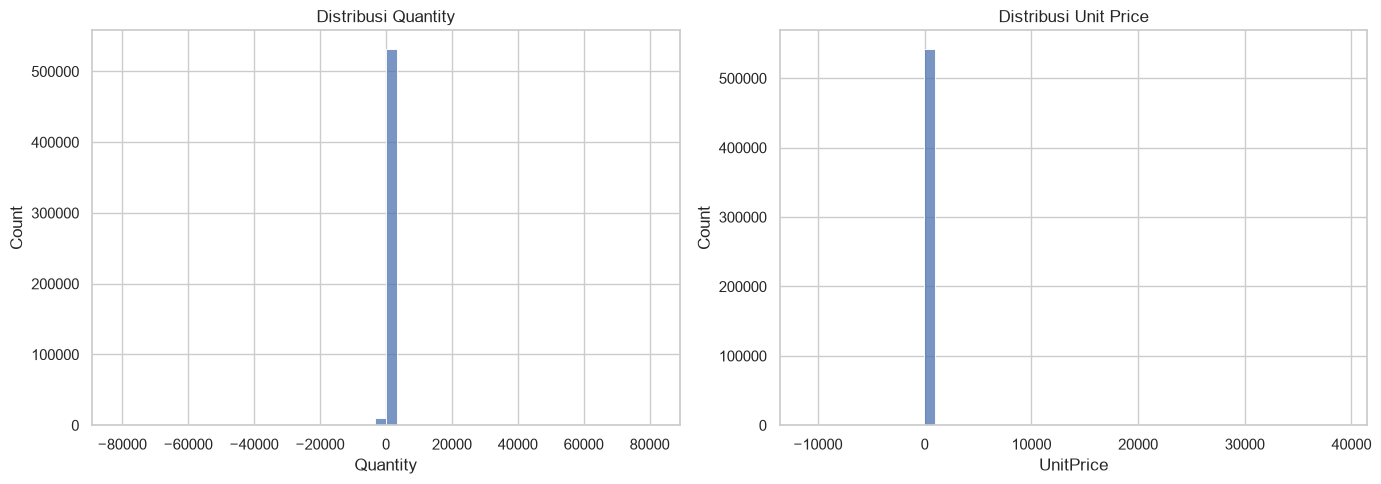

In [4]:
# Eksplorasi awal
print("Jumlah invoice:", df["InvoiceNo"].nunique())
print("Jumlah customer:", df["CustomerID"].nunique())
print("Jumlah produk:", df["StockCode"].nunique())
print("Jumlah negara:", df["Country"].nunique())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["Quantity"], bins=50, ax=axes[0])
axes[0].set_title("Distribusi Quantity")

sns.histplot(df["UnitPrice"], bins=50, ax=axes[1])
axes[1].set_title("Distribusi Unit Price")

plt.tight_layout()
plt.show()


## 3. Data Preparation

Tahap ini membersihkan data transaksi sebelum membentuk fitur pelanggan.

Langkah utama:
1. Menghapus transaksi tanpa CustomerID.
2. Menghapus transaksi pembatalan.
3. Menghapus quantity yang tidak positif.
4. Menghapus unit price yang tidak positif.
5. Mengubah InvoiceDate menjadi tipe datetime.
6. Membuat nilai transaksi `Revenue = Quantity × UnitPrice`.
7. Mengagregasi transaksi menjadi satu baris per pelanggan.


In [5]:
# Salin data
data = df.copy()

# Konversi tanggal
data["InvoiceDate"] = pd.to_datetime(data["InvoiceDate"])

# Hapus CustomerID kosong
data = data.dropna(subset=["CustomerID"])

# Hapus invoice pembatalan
data = data[~data["InvoiceNo"].astype(str).str.startswith("C")]

# Hanya transaksi dengan quantity dan harga positif
data = data[(data["Quantity"] > 0) & (data["UnitPrice"] > 0)]

# Revenue
data["Revenue"] = data["Quantity"] * data["UnitPrice"]

print("Ukuran data setelah cleaning:", data.shape)
display(data.head())


Ukuran data setelah cleaning: (397884, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [6]:
# Feature Engineering: membentuk fitur pelanggan
reference_date = data["InvoiceDate"].max() + pd.Timedelta(days=1)

customer_features = data.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (reference_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("Revenue", "sum"),
    TotalQuantity=("Quantity", "sum"),
    UniqueProducts=("StockCode", "nunique")
).reset_index()

customer_features["AvgTransactionValue"] = (
    customer_features["Monetary"] /
    customer_features["Frequency"]
)

customer_features = customer_features.replace([np.inf, -np.inf], np.nan).dropna()

print("Ukuran data pelanggan:", customer_features.shape)
display(customer_features.head())


Ukuran data pelanggan: (4338, 7)


,CustomerID,Recency,Frequency,Monetary,TotalQuantity,UniqueProducts,AvgTransactionValue
0,12346.0,326,1,77183.60,74215,1,77183.600000
1,12347.0,2,7,4310.00,2458,103,615.714286
2,12348.0,75,4,1797.24,2341,22,449.310000
3,12349.0,19,1,1757.55,631,73,1757.550000
4,12350.0,310,1,334.40,197,17,334.400000


,Recency,Frequency,Monetary,TotalQuantity,UniqueProducts,AvgTransactionValue
count,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460,1191.289073,61.501153,419.166289
std,100.014169,7.697998,8989.230441,5046.081546,85.366768,1796.537944
min,1.000000,1.000000,3.750000,1.000000,1.000000,3.450000
25%,18.000000,1.000000,307.415000,160.000000,16.000000,178.625000
50%,51.000000,2.000000,674.485000,379.000000,35.000000,293.900000
75%,142.000000,5.000000,1661.740000,992.750000,77.000000,430.113750
max,374.000000,209.000000,280206.020000,196915.000000,1787.000000,84236.250000


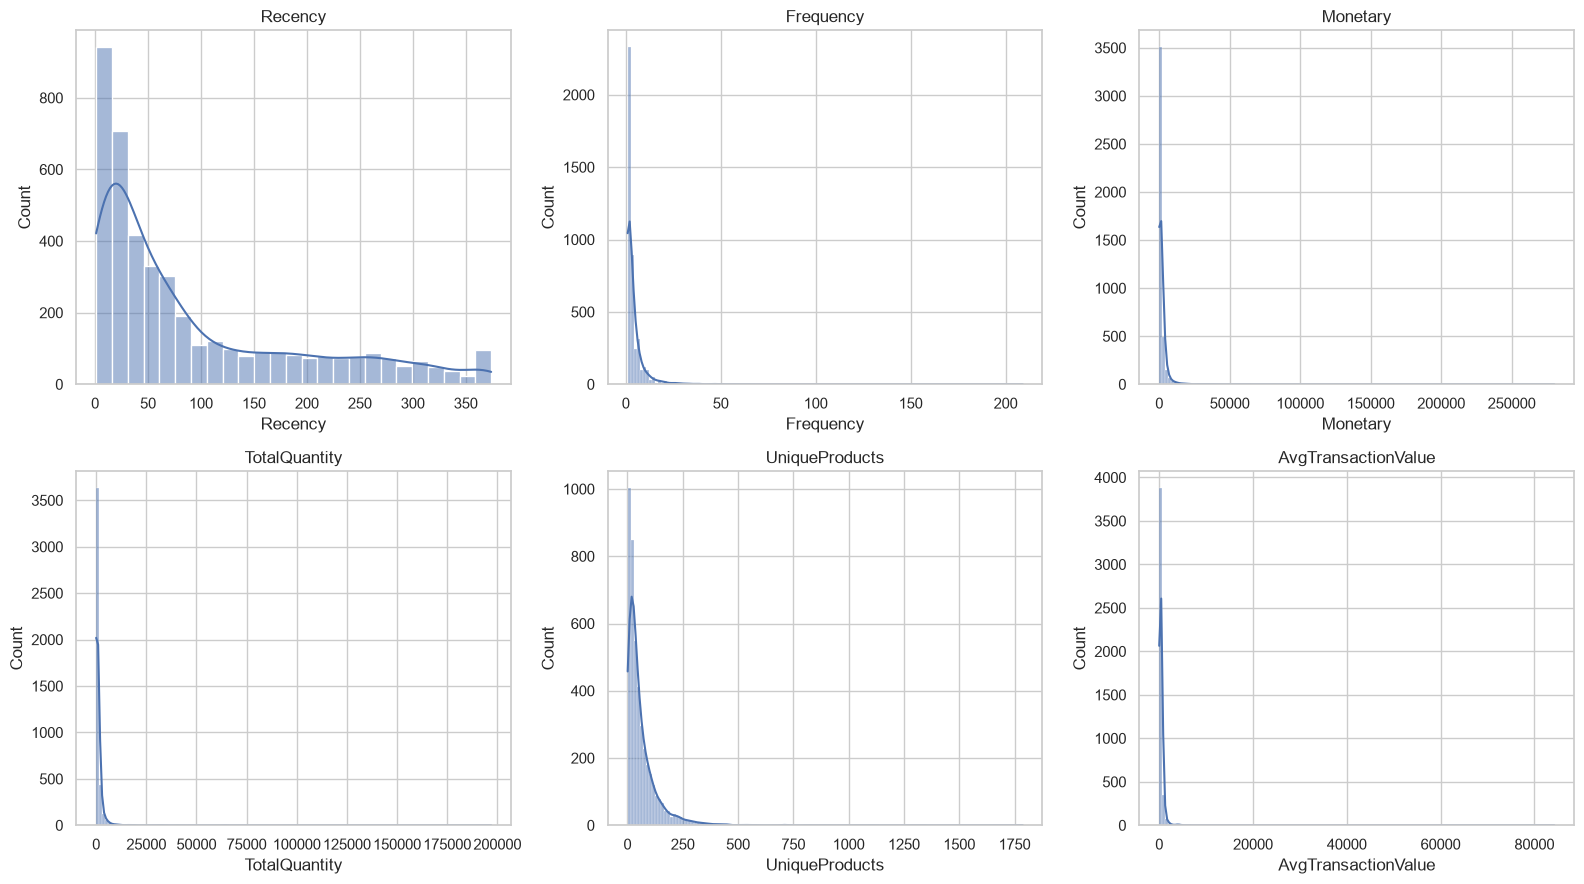

In [7]:
# Distribusi fitur hasil feature engineering
feature_cols = [
    "Recency", "Frequency", "Monetary",
    "TotalQuantity", "UniqueProducts",
    "AvgTransactionValue"
]

display(customer_features[feature_cols].describe())

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.ravel(), feature_cols):
    sns.histplot(customer_features[col], kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


### Transformasi log dan standardisasi

Data transaksi retail biasanya memiliki distribusi yang sangat miring. Karena itu, fitur numerik ditransformasi menggunakan `log1p` sebelum standardisasi.

Standardisasi diperlukan agar fitur dengan skala besar tidak mendominasi perhitungan jarak K-Means.


In [8]:
# Log transform
X_log = np.log1p(customer_features[feature_cols])

# Standardisasi
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)

display(X_scaled_df.describe().round(2))


,Recency,Frequency,Monetary,TotalQuantity,UniqueProducts,AvgTransactionValue
count,4338.00,4338.00,4338.00,4338.00,4338.00,4338.00
mean,-0.00,-0.00,0.00,0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.34,-0.96,-4.00,-3.86,-2.53,-5.58
25%,-0.66,-0.96,-0.69,-0.66,-0.63,-0.62
50%,0.09,-0.36,-0.06,-0.03,0.03,0.05
75%,0.84,0.65,0.65,0.67,0.71,0.56
max,1.56,5.86,4.73,4.53,3.48,7.64


## 4. Modeling

Algoritma yang digunakan adalah **K-Means Clustering**.

K-Means mengelompokkan data berdasarkan kedekatan terhadap centroid. Nilai `k` tidak ditentukan secara sembarang. Project membandingkan beberapa nilai k menggunakan:

- Elbow Method
- Silhouette Score


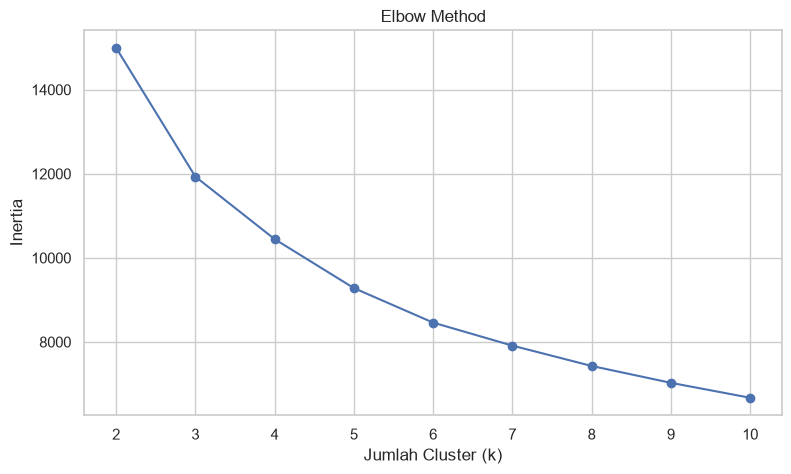

In [9]:
# Elbow Method
inertias = []
k_values = range(2, 11)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(list(k_values), inertias, marker="o")
plt.xlabel("Jumlah Cluster (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.xticks(list(k_values))
plt.show()


,k,Silhouette Score
0,2,0.356413
1,3,0.261537
2,4,0.225674
3,5,0.226933
4,6,0.212879
5,7,0.206729
6,8,0.206690
7,9,0.203901
8,10,0.195372


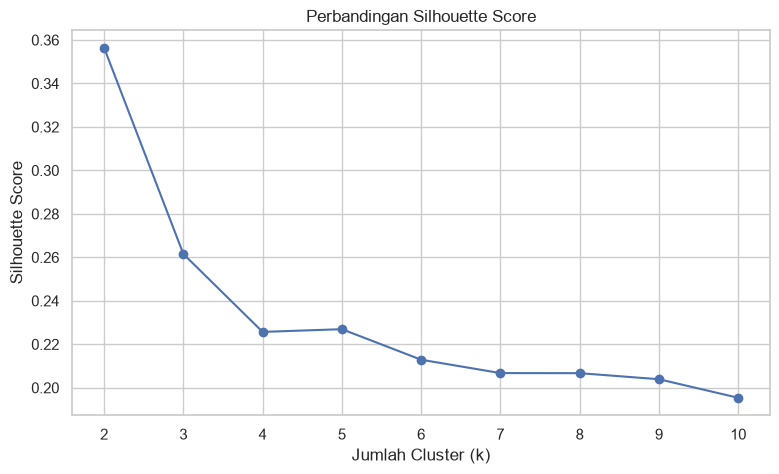

k dengan Silhouette Score tertinggi: 2


In [10]:
# Silhouette Score untuk beberapa k
silhouette_scores = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

silhouette_df = pd.DataFrame({
    "k": list(k_values),
    "Silhouette Score": silhouette_scores
})

display(silhouette_df)

plt.figure(figsize=(9, 5))
plt.plot(silhouette_df["k"], silhouette_df["Silhouette Score"], marker="o")
plt.xlabel("Jumlah Cluster (k)")
plt.ylabel("Silhouette Score")
plt.title("Perbandingan Silhouette Score")
plt.xticks(list(k_values))
plt.show()

best_k = int(
    silhouette_df.loc[
        silhouette_df["Silhouette Score"].idxmax(), "k"
    ]
)

print("k dengan Silhouette Score tertinggi:", best_k)


### Catatan pemilihan k

Gunakan hasil grafik Elbow dan tabel Silhouette Score untuk mendukung keputusan jumlah cluster. Pada project ini, `best_k` dipilih berdasarkan Silhouette Score tertinggi. Hasil akhir tetap harus diperiksa secara bisnis melalui profil setiap cluster.


In [11]:
# Model final
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

customer_features["Cluster"] = kmeans.fit_predict(X_scaled)

print("Model K-Means berhasil dibuat.")
display(customer_features.head())


Model K-Means berhasil dibuat.


,CustomerID,Recency,Frequency,Monetary,TotalQuantity,UniqueProducts,AvgTransactionValue,Cluster
0,12346.0,326,1,77183.60,74215,1,77183.600000,1
1,12347.0,2,7,4310.00,2458,103,615.714286,1
2,12348.0,75,4,1797.24,2341,22,449.310000,1
3,12349.0,19,1,1757.55,631,73,1757.550000,1
4,12350.0,310,1,334.40,197,17,334.400000,0


## 5. Evaluation

Evaluasi dilakukan dengan Silhouette Score dan analisis profil cluster.

Silhouette Score mendekati 1 menunjukkan pemisahan cluster yang lebih jelas. Nilai yang mendekati 0 menunjukkan titik data berada dekat dengan batas antarcluster.


In [12]:
# Evaluasi final
final_silhouette = silhouette_score(X_scaled, customer_features["Cluster"])

print(f"Jumlah cluster: {best_k}")
print(f"Silhouette Score: {final_silhouette:.4f}")


Jumlah cluster: 2
Silhouette Score: 0.3564


In [13]:
# Profil cluster
cluster_profile = (
    customer_features
    .groupby("Cluster")[feature_cols]
    .agg(["count", "mean", "median"])
    .round(2)
)

display(cluster_profile)


Recency                Frequency              Monetary           \
          count    mean median     count  mean median    count     mean   
Cluster                                                                   
0          2400  136.34   99.0      2400  1.64    1.0     2400   386.45   
1          1938   38.29   22.0      1938  7.53    5.0     1938  4119.68   

                 TotalQuantity                  UniqueProducts                 \
          median         count     mean  median          count    mean median   
Cluster                                                                         
0         328.60          2400   229.19   179.0           2400   23.74   19.0   
1        1844.66          1938  2382.75  1084.0           1938  108.27   82.0   

        AvgTransactionValue                  
                      count    mean  median  
Cluster                                      
0                      2400  262.98  213.62  
1                      1938  612.58  375.77

In [14]:
# Ringkasan yang lebih mudah dibaca
cluster_summary = (
    customer_features
    .groupby("Cluster")[feature_cols]
    .mean()
    .round(2)
)

cluster_summary["CustomerCount"] = (
    customer_features["Cluster"].value_counts().sort_index()
)

display(cluster_summary)


,Recency,Frequency,Monetary,TotalQuantity,UniqueProducts,AvgTransactionValue,CustomerCount
Cluster,,,,,,,
0,136.34,1.64,386.45,229.19,23.74,262.98,2400
1,38.29,7.53,4119.68,2382.75,108.27,612.58,1938


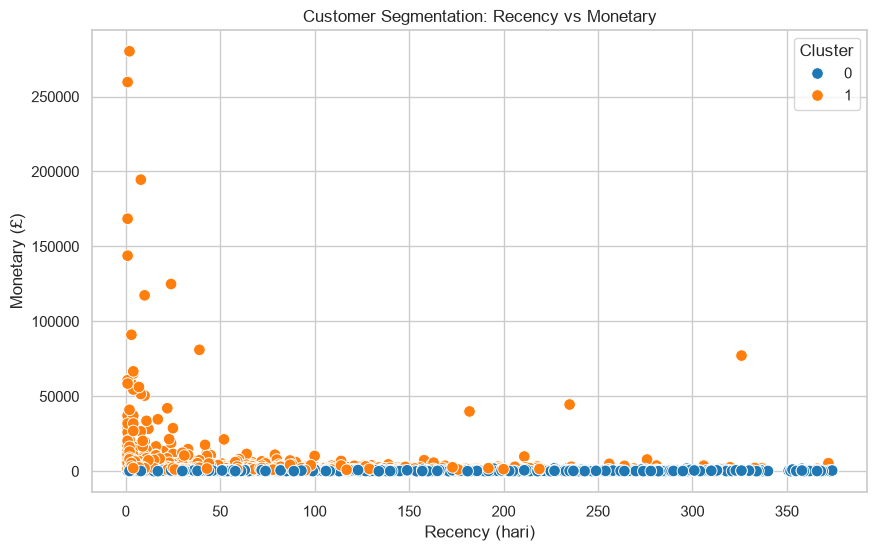

In [15]:
# Visualisasi dua fitur utama
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=customer_features,
    x="Recency",
    y="Monetary",
    hue="Cluster",
    palette="tab10",
    s=70
)
plt.title("Customer Segmentation: Recency vs Monetary")
plt.xlabel("Recency (hari)")
plt.ylabel("Monetary (£)")
plt.show()


### Interpretasi Cluster

Gunakan `cluster_summary` sebagai dasar interpretasi.

Panduan:
- **Recency rendah**: pelanggan relatif baru melakukan transaksi.
- **Frequency tinggi**: pelanggan melakukan transaksi lebih sering.
- **Monetary tinggi**: pelanggan menghasilkan nilai pembelian lebih besar.
- **TotalQuantity tinggi**: pelanggan membeli jumlah barang lebih banyak.
- **UniqueProducts tinggi**: pelanggan membeli variasi produk lebih banyak.
- **AvgTransactionValue tinggi**: rata-rata nilai transaksi pelanggan lebih besar.

Nama seperti "pelanggan bernilai tinggi" atau "pelanggan bertransaksi rendah" hanya diberikan setelah melihat nilai aktual setiap cluster.


## 6. Deployment Preparation

Model dan hasil segmentasi disimpan agar dapat digunakan oleh aplikasi Streamlit.


In [16]:
# Simpan hasil
customer_features.to_csv("customer_features.csv", index=False)
customer_features.to_csv("customer_segments.csv", index=False)
cluster_summary.to_csv("cluster_summary.csv")

joblib.dump(kmeans, "kmeans_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("File deployment berhasil dibuat:")
for filename in [
    "customer_features.csv",
    "customer_segments.csv",
    "cluster_summary.csv",
    "kmeans_model.pkl",
    "scaler.pkl"
]:
    print("-", filename)


File deployment berhasil dibuat:
- customer_features.csv
- customer_segments.csv
- cluster_summary.csv
- kmeans_model.pkl
- scaler.pkl


## 7. Deployment

Aplikasi dibuat menggunakan Streamlit.

Jalankan:

```bash
pip install -r requirements.txt
streamlit run app.py
```

Untuk deployment online, upload `app.py`, `requirements.txt`, serta file hasil model dan data ke repository GitHub, kemudian deploy melalui Streamlit Community Cloud.


## 8. Kesimpulan

Project ini menerapkan CRISP-DM untuk melakukan segmentasi pelanggan berdasarkan pola transaksi. Data transaksi dibersihkan dan diubah menjadi fitur pelanggan seperti Recency, Frequency, Monetary, TotalQuantity, UniqueProducts, dan AvgTransactionValue.

K-Means digunakan untuk menemukan kelompok pelanggan. Jumlah cluster dipilih dengan mempertimbangkan Elbow Method dan Silhouette Score. Hasil akhirnya dapat digunakan untuk memahami perbedaan perilaku pelanggan dan ditampilkan melalui aplikasi Streamlit.

**Penting:** isi kesimpulan akhir dengan angka aktual dari hasil notebook, terutama jumlah pelanggan, jumlah cluster, dan Silhouette Score.
